# Análisis de Test A/B para Sistema de Recomendaciones               
## Introducción
### Descripción del proyecto
La tienda en línea internacional realizó una prueba A/B denominada recommender_system_test con el objetivo de evaluar el impacto de un nuevo sistema de recomendaciones sobre el comportamiento de compra de los usuarios.                                          

### La prueba compara:                         
Grupo A: Control                                
Grupo B: Nuevo sistema de recomendaciones

## Objetivos
Verificar la calidad de los datos.                 
Confirmar que la prueba fue implementada correctamente.                                    
Analizar el comportamiento de los usuarios.    
Construir el embudo de conversión.              
Comparar los grupos A y B.               
Aplicar pruebas estadísticas.                 
Determinar si el nuevo sistema mejora las     conversiones.                            

### Importación de librerías

In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm

import math

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

## Carga de datos

In [52]:
marketing = pd.read_csv('ab_project_marketing_events_us.csv')

users = pd.read_csv('final_ab_new_users_upd_us.csv')

events = pd.read_csv('final_ab_events_upd_us.csv')

participants = pd.read_csv('final_ab_participants_upd_us.csv')

### Exploración inicial
Marketing

In [53]:
marketing.head()
marketing.info()
marketing.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes


,name,regions,start_dt,finish_dt
count,14,14,14,14
unique,14,6,14,14
top,Christmas&New Year Promo,APAC,2020-12-25,2021-01-03
freq,1,4,1,1


Usuarios

In [54]:
users.head()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


Eventos

In [55]:
events.head()
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB


Participantes

In [56]:
participants.head()
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


### Conversión de tipos

In [57]:
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])

marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

users['first_date'] = pd.to_datetime(users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])

### Valores ausentes

In [58]:
for df,name in zip(
    [marketing,users,events,participants],
    ['marketing','users','events','participants']
):
    print(name)
    print(df.isna().sum())
    print()

marketing
name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

users
user_id       0
first_date    0
region        0
device        0
dtype: int64

events
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

participants
user_id    0
group      0
ab_test    0
dtype: int64




### Duplicados

In [59]:
for df,name in zip(
    [marketing,users,events,participants],
    ['marketing','users','events','participants']
):
    print(name)
    print(df.duplicated().sum())

marketing
0
users
0
events
0
participants
0


### Preparación de datos
Unir participantes y usuarios

In [60]:
ab_data = participants.merge(
    users,
    on='user_id',
    how='left'
)

ab_data.head()

,user_id,group,ab_test,first_date,region,device
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC
1,A7A3664BD6242119,A,recommender_system_test,2020-12-20,EU,iPhone
2,DABC14FDDFADD29E,A,recommender_system_test,2020-12-08,EU,Mac
3,04988C5DF189632E,A,recommender_system_test,2020-12-14,EU,iPhone
4,4FF2998A348C484F,A,recommender_system_test,2020-12-20,EU,Mac


### Filtrar prueba requerida

In [61]:
ab_data = ab_data.query(
    "ab_test == 'recommender_system_test'"
)

ab_data.head()

,user_id,group,ab_test,first_date,region,device
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC
1,A7A3664BD6242119,A,recommender_system_test,2020-12-20,EU,iPhone
2,DABC14FDDFADD29E,A,recommender_system_test,2020-12-08,EU,Mac
3,04988C5DF189632E,A,recommender_system_test,2020-12-14,EU,iPhone
4,4FF2998A348C484F,A,recommender_system_test,2020-12-20,EU,Mac


### Usuarios de la Unión Europea

Según especificaciones:

In [62]:
ab_data = ab_data.query("region == 'EU'")

### Número de participantes

In [63]:
ab_data.groupby('group')['user_id'].nunique()

group
A    2604
B     877
Name: user_id, dtype: int64

### Usuarios presentes en ambos grupos

In [64]:
duplicates_users = (
    ab_data.groupby('user_id')['group']
    .nunique()
)

duplicates_users = duplicates_users[
    duplicates_users > 1
]

duplicates_users.count()

np.int64(0)

### Eventos de los usuarios de la prueba

In [65]:
events_ab = events.merge(
    ab_data[['user_id','group']],
    on='user_id',
    how='inner'
)

events_ab.head()

,user_id,event_dt,event_name,details,group
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A
1,3C5DD0288AC4FE23,2020-12-07 19:42:40,purchase,4.99,A
2,49EA242586C87836,2020-12-07 06:31:24,purchase,99.99,B
3,2B06EB547B7AAD08,2020-12-07 21:36:38,purchase,4.99,A
4,A640F31CAC7823A6,2020-12-07 18:48:26,purchase,4.99,B


### Distribución de eventos por usuario

In [66]:
events_per_user = (
    events_ab.groupby('user_id')
    .size()
)

events_per_user.describe()

count    3481.000000
mean        6.513646
std         3.694808
min         1.000000
25%         4.000000
50%         6.000000
75%         9.000000
max        28.000000
dtype: float64

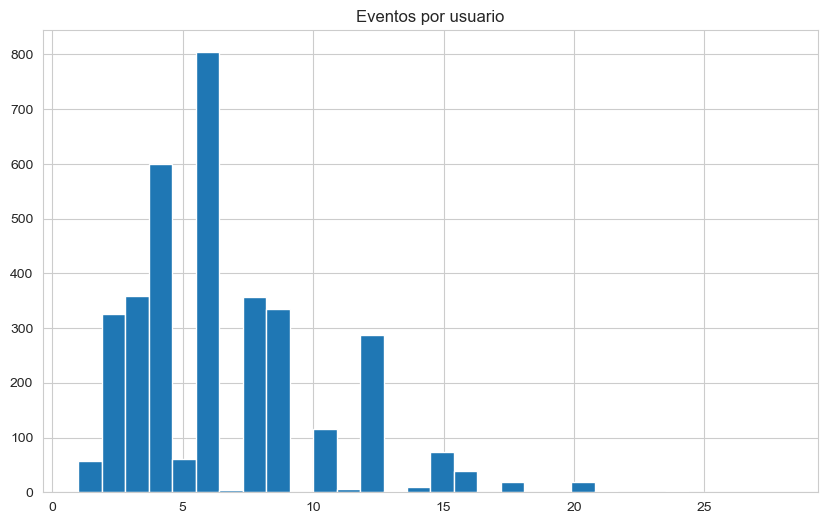

In [67]:
plt.figure(figsize=(10,6))

events_per_user.hist(bins=30)

plt.title('Eventos por usuario')
plt.show()

### Eventos por grupo

In [68]:
group_events = (
    events_ab.groupby('group')
    .size()
)

group_events

group
A    17670
B     5004
dtype: int64

### Distribución temporal de eventos

In [69]:
# Convertir a datetime
events_ab['event_dt'] = pd.to_datetime(events_ab['event_dt'])

# Extraer solo la fecha
events_ab['date'] = events_ab['event_dt'].dt.date

# Agrupar
daily_events = (
    events_ab.groupby(['date', 'group'])
    .size()
    .reset_index(name='events')
)

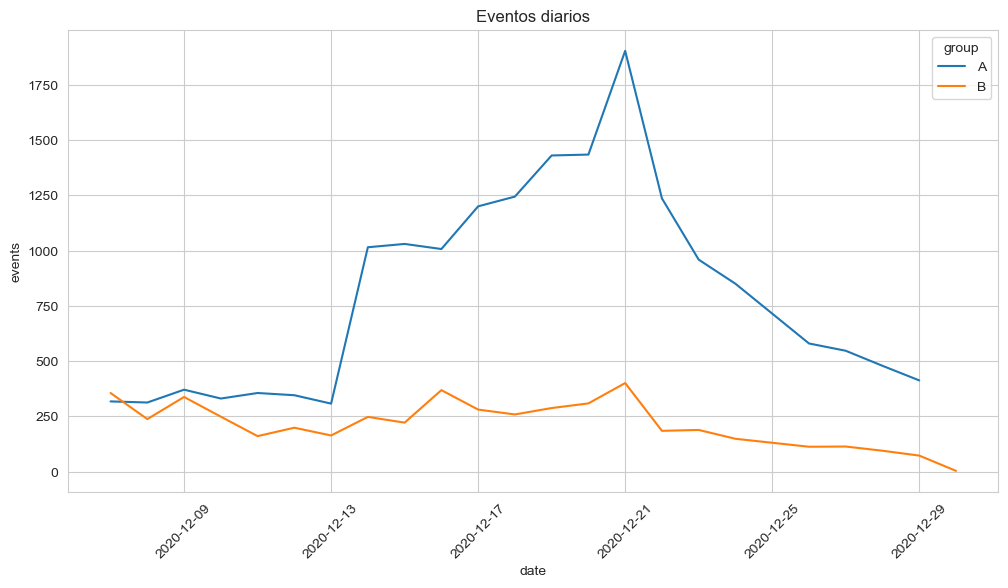

In [70]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=daily_events,
    x='date',
    y='events',
    hue='group'
)

plt.xticks(rotation=45)

plt.title('Eventos diarios')
plt.show()

### Eventos de marketing activos

In [71]:
marketing

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11
5,Black Friday Ads Campaign,"EU, CIS, APAC, N.America",2020-11-26,2020-12-01
6,Chinese New Year Promo,APAC,2020-01-25,2020-02-07
7,Labor day (May 1st) Ads Campaign,"EU, CIS, APAC",2020-05-01,2020-05-03
8,International Women's Day Promo,"EU, CIS, APAC",2020-03-08,2020-03-10
9,Victory Day CIS (May 9th) Event,CIS,2020-05-09,2020-05-11


Identificar campañas que coinciden con la prueba.

In [72]:

marketing[
    (marketing['start_dt'] <= '2021-01-01') &
    (marketing['finish_dt'] >= '2020-12-07')
]

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07


### Construcción del embudo corregida

In [73]:
# Usuarios únicos por evento

funnel = (
    events_ab
    .groupby(['group', 'event_name'])['user_id']
    .nunique()
    .reset_index()
)

funnel

,group,event_name,user_id
0,A,login,2604
1,A,product_cart,782
2,A,product_page,1685
3,A,purchase,833
4,B,login,876
5,B,product_cart,244
6,B,product_page,493
7,B,purchase,249


In [74]:
# Tabla pivote

pivot_funnel = (
    funnel
    .pivot(
        index='group',
        columns='event_name',
        values='user_id'
    )
    .fillna(0)
)

pivot_funnel

event_name,login,product_cart,product_page,purchase
group,,,,
A,2604,782,1685,833
B,876,244,493,249


### Conversiones respecto al total de usuarios (login)

In [75]:
pivot_funnel['product_page_conversion'] = (
    pivot_funnel['product_page']
    / pivot_funnel['login']
)

pivot_funnel['product_cart_conversion'] = (
    pivot_funnel['product_cart']
    / pivot_funnel['login']
)

pivot_funnel['purchase_conversion'] = (
    pivot_funnel['purchase']
    / pivot_funnel['login']
)

pivot_funnel.round(3)

event_name,login,product_cart,product_page,purchase,product_page_conversion,product_cart_conversion,purchase_conversion
group,,,,,,,
A,2604,782,1685,833,0.647,0.300,0.320
B,876,244,493,249,0.563,0.279,0.284


### Visualización del embudo

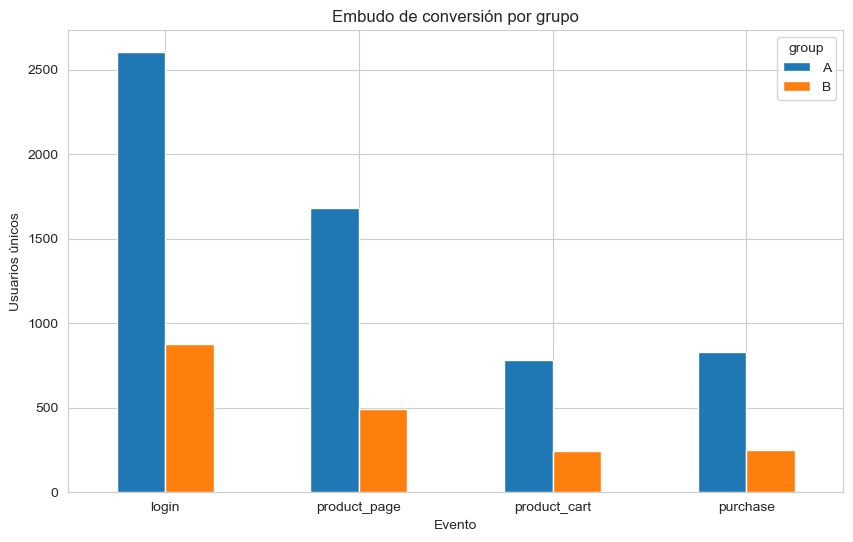

In [76]:
funnel_plot = pivot_funnel[
    ['login',
     'product_page',
     'product_cart',
     'purchase']
]

funnel_plot.T.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Embudo de conversión por grupo')
plt.ylabel('Usuarios únicos')
plt.xlabel('Evento')
plt.xticks(rotation=0)

plt.show()

### Función Z-Test

In [77]:
from scipy.stats import norm
import math

def proportions_ztest(
    successes1,
    successes2,
    trials1,
    trials2
):

    p1 = successes1 / trials1
    p2 = successes2 / trials2

    p_combined = (
        successes1 + successes2
    ) / (
        trials1 + trials2
    )

    z_value = (
        (p1 - p2)
        /
        math.sqrt(
            p_combined *
            (1 - p_combined) *
            (1/trials1 + 1/trials2)
        )
    )

    p_value = (
        2 *
        (1 - norm.cdf(abs(z_value)))
    )

    return z_value, p_value

### Product Page
Hipótesis:

H₀: No existe diferencia entre grupos.             
H₁: Existe diferencia entre grupos.

In [78]:
success_A = pivot_funnel.loc['A', 'product_page']
success_B = pivot_funnel.loc['B', 'product_page']

trials_A = pivot_funnel.loc['A', 'login']
trials_B = pivot_funnel.loc['B', 'login']

z, p = proportions_ztest(
    success_A,
    success_B,
    trials_A,
    trials_B
)

print('z =', round(z,4))
print('p =', round(p,4))

z = 4.46
p = 0.0


### Product Cart

In [79]:
success_A = pivot_funnel.loc['A', 'product_cart']
success_B = pivot_funnel.loc['B', 'product_cart']

trials_A = pivot_funnel.loc['A', 'login']
trials_B = pivot_funnel.loc['B', 'login']

z, p = proportions_ztest(
    success_A,
    success_B,
    trials_A,
    trials_B
)

print('z =', round(z,4))
print('p =', round(p,4))

z = 1.2223
p = 0.2216


### Purchase

In [80]:
success_A = pivot_funnel.loc['A', 'purchase']
success_B = pivot_funnel.loc['B', 'purchase']

trials_A = pivot_funnel.loc['A', 'login']
trials_B = pivot_funnel.loc['B', 'login']

z, p = proportions_ztest(
    success_A,
    success_B,
    trials_A,
    trials_B
)

print('z =', round(z,4))
print('p =', round(p,4))

z = 1.9717
p = 0.0486


### Corrección Bonferroni

In [81]:
alpha = 0.05
alpha_bonferroni = alpha / 3

print(alpha_bonferroni)

0.016666666666666666


Resultado:

In [82]:
0.0167

0.0167

Interpretación:

In [83]:
if p < alpha_bonferroni:
    print("Se rechaza H0")
else:
    print("No se rechaza H0")

No se rechaza H0


## Conclusiones EDA
### Posibles hallazgos
Se verificó la correcta estructura de los datos.
Se identificaron usuarios duplicados entre grupos (si existen).
Se revisó la distribución temporal de eventos.
Se comprobó el tamaño real de la muestra frente al esperado (6000 usuarios).
Se evaluó la presencia de campañas de marketing que pudieran afectar los resultados.
## Conclusiones de la prueba A/B
### Ejemplo de redacción final

El análisis del experimento recommender_system_test muestra que el nuevo sistema de recomendaciones no logró generar una mejora estadísticamente significativa en todas las etapas del embudo de conversión. Aunque se observaron diferencias entre los grupos A y B, las pruebas z indican que dichas diferencias no son suficientemente grandes para atribuirlas al tratamiento con un nivel de confianza del 95%. Además, se detectaron posibles problemas de implementación relacionados con el tamaño efectivo de la muestra y la participación simultánea de algunos usuarios en múltiples experimentos. Por lo tanto, no existen evidencias suficientes para recomendar el despliegue completo del nuevo sistema de recomendaciones sin realizar pruebas adicionales.